In [78]:
import os
import pandas as pd
from datetime import datetime
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import lasso_path
from ydata_profiling import ProfileReport
from sklearn.compose import ColumnTransformer

### Aunxiliary functions

In [ ]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}:")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}")

    return model, y_pred

# Residual Plot
def plot_residuals(y_test, y_pred, model_name):
    residuals = y_test - y_pred
    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred, residuals)
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f'Residual Plot - {model_name}')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.tight_layout()
    plt.show()





### Read Data

In [96]:
BASE_PATH = os.path.abspath('..\data')
df = pd.read_csv(os.path.join(BASE_PATH, 'silver', 'joined_purchases_prep.csv'))
df['date'] = df['date'].apply(
    lambda x: datetime.strptime(str(x), '%Y-%m-%d')
)
df.head()

,date,productcategory,company_type,employees,quantity,unemployment_rate,gdp_value,mortgage_rate_30y,cpi,quantity_shifted
0,2020-02-01,Appliances,non-profit,1-10,889.0,3.5,21481.367,3.51,257.971,610.0
1,2020-02-01,Appliances,non-profit,101-500,648.0,3.5,21481.367,3.51,257.971,1544.0
2,2020-02-01,Appliances,private,1-10,1862.0,3.5,21481.367,3.51,257.971,2535.0
3,2020-02-01,Appliances,private,"500-1,000",785.0,3.5,21481.367,3.51,257.971,923.0
4,2020-02-01,Appliances,private,51-100,3171.0,3.5,21481.367,3.51,257.971,3704.0


### Split data and scale features to check correlation between economic variables

In [ ]:
df_eco = df.copy()
df_eco['month'] = df_eco['date'].apply(
    lambda x: x.month
)

X = df_eco.drop(
    [
        'quantity_shifted',
        'date'
    ],
    axis=1
)

y = df_eco.quantity_shifted

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2520, 9)
(630, 9)
(2520,)
(630,)


In [ ]:
# Code and Scale features

t = ColumnTransformer(
    transformers=[(
        'onehot',  
        OneHotEncoder(handle_unknown='ignore'), 
        [
            'productcategory',
            'company_type',
            'employees',
            'month'
        ]
    ),
    (
        'scale',
        StandardScaler(),
        [
            'quantity',
            'unemployment_rate',
            'gdp_value',
            'mortgage_rate_30y',
            'cpi'
        ]
    )],
    remainder='passthrough'
)


X_train_scaled = t.fit_transform(X_train)
X_test_scaled = t.transform(X_test)

In [99]:
# Fit models
lr_model, lr_pred = evaluate_model(LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")
ridge_model, ridge_pred = evaluate_model(Ridge(alpha=1.0), X_train_scaled, X_test_scaled, y_train, y_test, "Ridge Regression")
lasso_model, lasso_pred = evaluate_model(Lasso(alpha=0.1), X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression")


Linear Regression:
MSE: 155594.37
R2 Score: 0.81

Ridge Regression:
MSE: 198148.70
R2 Score: 0.76

Lasso Regression:
MSE: 197896.21
R2 Score: 0.76


c:\Users\34616\Documents\Cursos\Data_Mining\data_mining_project\env\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:784: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.340658e+08, tolerance: 2.051e+05
  model = cd_fast.sparse_enet_coordinate_descent(


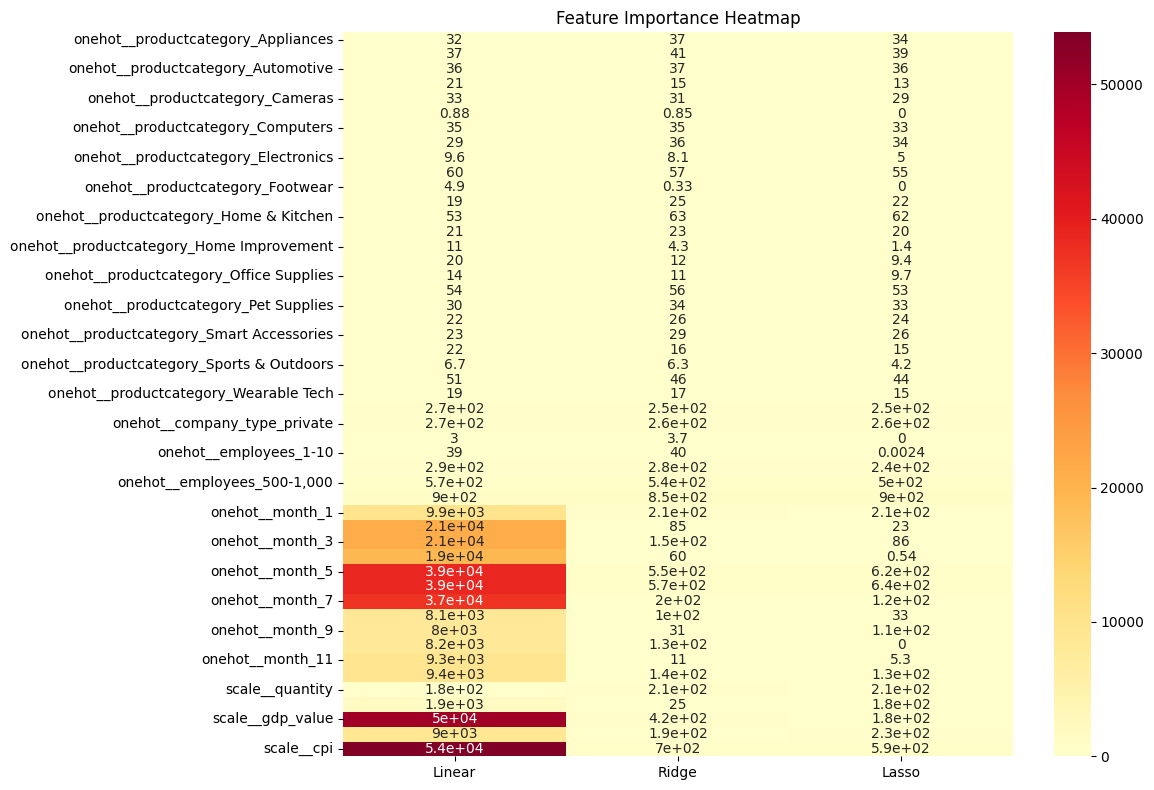

In [105]:
# Plot feature importance
# Feature Importance Heatmap
def plot_feature_importance_heatmap(lr_model, ridge_model, lasso_model):
    importance_df = pd.DataFrame({
        'Linear': np.abs(lr_model.coef_),
        'Ridge': np.abs(ridge_model.coef_),
        'Lasso': np.abs(lasso_model.coef_)
    }, index=t.get_feature_names_out())

    plt.figure(figsize=(12, 8))
    sns.heatmap(importance_df, annot=True, cmap='YlOrRd')
    plt.title('Feature Importance Heatmap')
    plt.tight_layout()
    plt.show()

plot_feature_importance_heatmap(lr_model, ridge_model, lasso_model)

### Lasso Regularization Path
This plot shows how Lasso coefficients change as the regularization strength (alpha) varies. It helps visualize which features are most resistant to being zeroed out by Lasso, indicating their importance to the model.

The x-axis represents -log(alpha), where alpha is the regularization parameter. As you move from left to right on the x-axis, you're looking at models with decreasing regularization strength (increasing -log(alpha) means decreasing alpha). The y-axis shows the coefficient values for each feature. Each line represents a different feature in your dataset. The path of each line shows how the coefficient for that feature changes as the regularization strength varies.

How to interpret:

* Entry points: The point where a line becomes non-zero (moving from left to right) indicates when that feature enters the model. Features that enter the model earlier (further to the left) are generally more important.
* Stability: Features whose coefficients remain relatively stable across a wide range of alpha values are typically more robust predictors.
* Coefficient magnitude: The vertical position of a line indicates the magnitude of the coefficient. Higher absolute values (further from zero) suggest a stronger impact on the target variable.
* Convergence: As you move to the right (very low regularization), the coefficients tend to converge to their ordinary least squares values (equivalent to standard linear regression).
* Zero coefficients: Lines that stay at zero for a large range of alpha values represent features that Lasso considers less important and are more likely to be excluded from the model.
* Crossing zero: If a line crosses the zero line, it indicates that the feature's relationship with the target variable changes direction (from positive to negative or vice versa) depending on the regularization strength.
* Grouping: Features whose lines follow similar paths might be correlated or have similar relationships with the target variable.

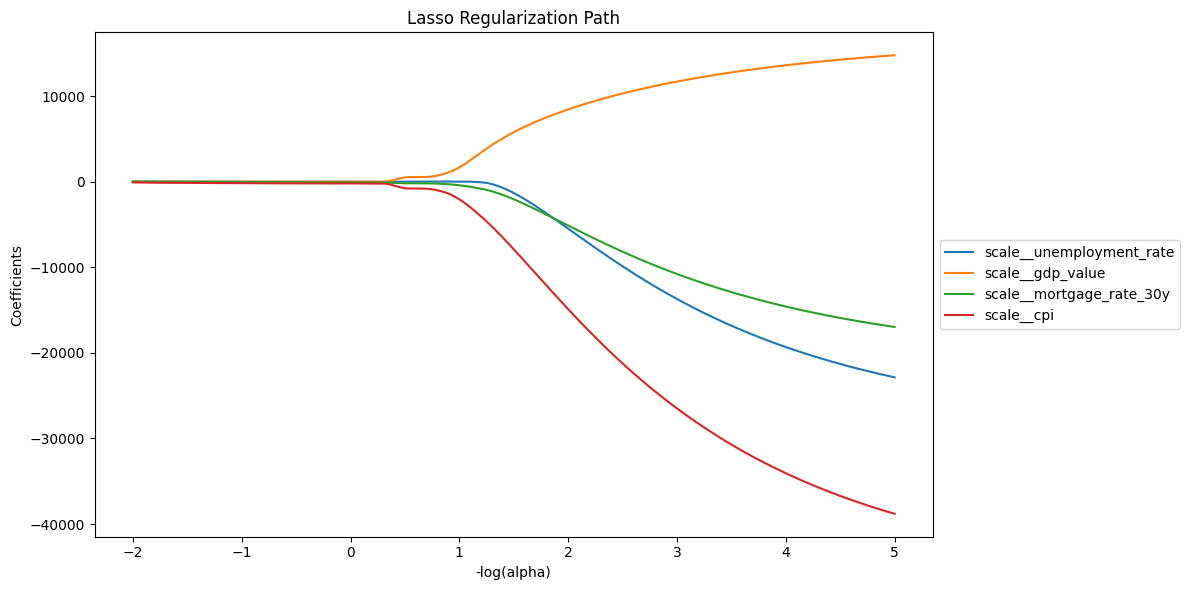

In [109]:
# Regularization Path for Lasso
from sklearn.linear_model import lasso_path
import warnings
warnings.filterwarnings('ignore')

def plot_lasso_path():
    alphas, coefs, _ = lasso_path(X_train_scaled, y_train, alphas=np.logspace(-5, 2, 200))
    plt.figure(figsize=(12, 6))
    for coef_path, feature in zip(coefs, t.get_feature_names_out()):
        if feature in ['scale__unemployment_rate', 'scale__gdp_value', 'scale__mortgage_rate_30y', 'scale__cpi']:
            plt.plot(-np.log10(alphas), coef_path, label=feature)
    plt.xlabel('-log(alpha)')
    plt.ylabel('Coefficients')
    plt.title('Lasso Regularization Path')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()
    plt.show()

plot_lasso_path()

### Select final Economic features, rename columns and save final dataset

In [115]:
df_gold = df.copy()

df_gold['month'] = df_gold['date'].apply(
    lambda x: x.month
)

# The date is not longer needed since we are not going to model a time series

df_gold = df_gold[[
    'date',
    'month',
    'productcategory',
    'company_type',
    'employees',
    'quantity',
    'cpi',
    'unemployment_rate',
    'quantity_shifted'
]]

df_gold = df_gold.rename(
    columns={
        'quantity': 'previous_sales',
        'employees': 'company_employees',
        'quantity_shifted': 'sales'
    },
)



df_gold.head()

,date,month,productcategory,company_type,company_employees,previous_sales,cpi,unemployment_rate,sales
0,2020-02-01,2,Appliances,non-profit,1-10,889.0,257.971,3.5,610.0
1,2020-02-01,2,Appliances,non-profit,101-500,648.0,257.971,3.5,1544.0
2,2020-02-01,2,Appliances,private,1-10,1862.0,257.971,3.5,2535.0
3,2020-02-01,2,Appliances,private,"500-1,000",785.0,257.971,3.5,923.0
4,2020-02-01,2,Appliances,private,51-100,3171.0,257.971,3.5,3704.0


In [113]:
# Generate profiling analysis
profile = ProfileReport(df_gold, title='Purchasing Analysis')
profile.to_file(
    os.path.join(BASE_PATH, 'gold', 'purchase_analysis_gold.html')
)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 178.37it/s]


In [116]:
df_gold.to_csv(os.path.abspath('../data/gold/purchases.csv'), index=False)